In [73]:
import pandas as pd

file_path = "/Users/manishrawool/Desktop/fairhome/857911_bundle_2/tranall_link_26122024.csv"

# Read ONLY the header row to see all 106 column names, without touching the data
columns = pd.read_csv(file_path, nrows=0).columns.tolist()
print(f"Total columns: {len(columns)}")
for i, col in enumerate(columns):
    print(i, col)
    

Total columns: 106
0 postcode
1 transactionid
2 price
3 dateoftransfer
4 propertytype
5 oldnew
6 duration
7 paon
8 saon
9 street
10 locality
11 towncity
12 district
13 county
14 categorytype
15 recordstatus
16 LMK_KEY
17 classt
18 lad23cd
19 BUILDING_REFERENCE_NUMBER
20 CURRENT_ENERGY_RATING
21 POTENTIAL_ENERGY_RATING
22 CURRENT_ENERGY_EFFICIENCY
23 POTENTIAL_ENERGY_EFFICIENCY
24 PROPERTY_TYPE
25 BUILT_FORM
26 INSPECTION_DATE
27 LOCAL_AUTHORITY
28 CONSTITUENCY
29 COUNTY
30 LODGEMENT_DATE
31 TRANSACTION_TYPE
32 ENVIRONMENT_IMPACT_CURRENT
33 ENVIRONMENT_IMPACT_POTENTIAL
34 ENERGY_CONSUMPTION_CURRENT
35 ENERGY_CONSUMPTION_POTENTIAL
36 CO2_EMISSIONS_CURRENT
37 CO2_EMISS_CURR_PER_FLOOR_AREA
38 CO2_EMISSIONS_POTENTIAL
39 LIGHTING_COST_CURRENT
40 LIGHTING_COST_POTENTIAL
41 HEATING_COST_CURRENT
42 HEATING_COST_POTENTIAL
43 HOT_WATER_COST_CURRENT
44 HOT_WATER_COST_POTENTIAL
45 TOTAL_FLOOR_AREA
46 ENERGY_TARIFF
47 MAINS_GAS_FLAG
48 FLOOR_LEVEL
49 FLAT_TOP_STOREY
50 FLAT_STOREY_COUNT
51 MAIN_HEAT

In [74]:
import pandas as pd

file_path = "/Users/manishrawool/Desktop/fairhome/857911_bundle_2/tranall_link_26122024.csv"

# Read ONLY the header row to see all 106 column names, without touching the data
columns = pd.read_csv(file_path, nrows=0).columns.tolist()
print(f"Total columns: {len(columns)}")
for i, col in enumerate(columns):
    print(i, col)

Total columns: 106
0 postcode
1 transactionid
2 price
3 dateoftransfer
4 propertytype
5 oldnew
6 duration
7 paon
8 saon
9 street
10 locality
11 towncity
12 district
13 county
14 categorytype
15 recordstatus
16 LMK_KEY
17 classt
18 lad23cd
19 BUILDING_REFERENCE_NUMBER
20 CURRENT_ENERGY_RATING
21 POTENTIAL_ENERGY_RATING
22 CURRENT_ENERGY_EFFICIENCY
23 POTENTIAL_ENERGY_EFFICIENCY
24 PROPERTY_TYPE
25 BUILT_FORM
26 INSPECTION_DATE
27 LOCAL_AUTHORITY
28 CONSTITUENCY
29 COUNTY
30 LODGEMENT_DATE
31 TRANSACTION_TYPE
32 ENVIRONMENT_IMPACT_CURRENT
33 ENVIRONMENT_IMPACT_POTENTIAL
34 ENERGY_CONSUMPTION_CURRENT
35 ENERGY_CONSUMPTION_POTENTIAL
36 CO2_EMISSIONS_CURRENT
37 CO2_EMISS_CURR_PER_FLOOR_AREA
38 CO2_EMISSIONS_POTENTIAL
39 LIGHTING_COST_CURRENT
40 LIGHTING_COST_POTENTIAL
41 HEATING_COST_CURRENT
42 HEATING_COST_POTENTIAL
43 HOT_WATER_COST_CURRENT
44 HOT_WATER_COST_POTENTIAL
45 TOTAL_FLOOR_AREA
46 ENERGY_TARIFF
47 MAINS_GAS_FLAG
48 FLOOR_LEVEL
49 FLAT_TOP_STOREY
50 FLAT_STOREY_COUNT
51 MAIN_HEAT

In [75]:
# The columns we shortlisted
cols_to_check = [
    "price", "dateoftransfer", "propertytype", "towncity", "county", "postcode",
    "TOTAL_FLOOR_AREA", "NUMBER_HABITABLE_ROOMS", "CURRENT_ENERGY_RATING",
    "CONSTRUCTION_AGE_BAND", "oldnew", "duration"
]

# Read just these columns, just the first 5 rows
preview = pd.read_csv(file_path, usecols=cols_to_check, nrows=5)

# Show all columns without pandas truncating them
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

preview

,postcode,price,dateoftransfer,propertytype,oldnew,duration,towncity,county,CURRENT_ENERGY_RATING,TOTAL_FLOOR_AREA,NUMBER_HABITABLE_ROOMS,CONSTRUCTION_AGE_BAND
0,SL4 1QN,960000,2023-02-24,F,N,L,WINDSOR,WINDSOR AND MAIDENHEAD,C,109,3,England and Wales: 2007 onwards
1,MK7 7DB,112000,1998-09-11,D,N,F,MILTON KEYNES,MILTON KEYNES,C,104,6,England and Wales: 1983-1990
2,SO16 8BW,251000,2021-05-28,T,N,F,SOUTHAMPTON,SOUTHAMPTON,D,102,5,England and Wales: 1976-1982
3,CW11 1SQ,69000,1997-10-10,D,N,L,SANDBACH,CHESHIRE,E,97,6,England and Wales: 1967-1975
4,CW9 6PR,253000,2021-09-28,D,N,F,NORTHWICH,CHESHIRE WEST AND CHESTER,E,79,4,England and Wales: 1976-1982


In [76]:
cols_to_keep = [
    "price", "dateoftransfer", "propertytype", "towncity", "county", "postcode",
    "TOTAL_FLOOR_AREA", "NUMBER_HABITABLE_ROOMS", "CURRENT_ENERGY_RATING",
    "CONSTRUCTION_AGE_BAND", "oldnew", "duration"
]

kept_chunks = []

# Chunked read keeps memory low — never holds all 22M rows at once
chunk_iterator = pd.read_csv(
    file_path,
    usecols=cols_to_keep,
    parse_dates=["dateoftransfer"],
    chunksize=500_000
)

for i, chunk in enumerate(chunk_iterator):
    recent = chunk[chunk["dateoftransfer"].dt.year >= 2015]
    kept_chunks.append(recent)
    print(f"Chunk {i+1}: read {len(chunk):,} rows, kept {len(recent):,}")

df = pd.concat(kept_chunks, ignore_index=True)
print(f"\nDone. Final dataset: {len(df):,} rows, {df.shape[1]} columns")

Chunk 1: read 500,000 rows, kept 193,598
Chunk 2: read 500,000 rows, kept 175,503
Chunk 3: read 500,000 rows, kept 176,103
Chunk 4: read 500,000 rows, kept 175,392
Chunk 5: read 500,000 rows, kept 175,829
Chunk 6: read 500,000 rows, kept 175,184
Chunk 7: read 500,000 rows, kept 175,556
Chunk 8: read 500,000 rows, kept 175,549
Chunk 9: read 500,000 rows, kept 175,074
Chunk 10: read 500,000 rows, kept 175,767
Chunk 11: read 500,000 rows, kept 175,574
Chunk 12: read 500,000 rows, kept 175,483
Chunk 13: read 500,000 rows, kept 175,119
Chunk 14: read 500,000 rows, kept 175,528
Chunk 15: read 500,000 rows, kept 176,275
Chunk 16: read 500,000 rows, kept 175,141
Chunk 17: read 500,000 rows, kept 175,583
Chunk 18: read 500,000 rows, kept 175,474
Chunk 19: read 500,000 rows, kept 175,528
Chunk 20: read 500,000 rows, kept 176,116
Chunk 21: read 500,000 rows, kept 175,472
Chunk 22: read 500,000 rows, kept 176,428
Chunk 23: read 500,000 rows, kept 175,870
Chunk 24: read 500,000 rows, kept 175,467
C

In [77]:
# Missing values per column, count + percentage
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)

summary = pd.DataFrame({"missing": missing, "percent": missing_pct})
print(summary.sort_values("missing", ascending=False))

                        missing  percent
NUMBER_HABITABLE_ROOMS  1276061       18
CONSTRUCTION_AGE_BAND     73873        1
postcode                      0        0
price                         0        0
dateoftransfer                0        0
propertytype                  0        0
oldnew                        0        0
duration                      0        0
towncity                      0        0
county                        0        0
CURRENT_ENERGY_RATING         0        0
TOTAL_FLOOR_AREA              0        0


In [78]:
# Drop the weak/gappy column, then drop the few rows missing age band
df = df.drop(columns=["NUMBER_HABITABLE_ROOMS"])
df = df.dropna(subset=["CONSTRUCTION_AGE_BAND"]).reset_index(drop=True)

# Map short codes to readable words (each column mapped separately, so F=Flat vs F=Freehold don't clash)
df["propertytype"] = df["propertytype"].map({
    "D": "Detached", "S": "Semi-Detached", "T": "Terraced", "F": "Flat", "O": "Other"
})
df["duration"] = df["duration"].map({"F": "Freehold", "L": "Leasehold"})
df["oldnew"] = df["oldnew"].map({"Y": "New Build", "N": "Existing"})

print(f"Rows: {len(df):,}, Columns: {df.shape[1]}")
print(df[["propertytype", "duration", "oldnew"]].value_counts().head(10))


Rows: 7,010,460, Columns: 11
propertytype   duration   oldnew   
Semi-Detached  Freehold   Existing     1716786
Terraced       Freehold   Existing     1707324
Detached       Freehold   Existing     1464705
Flat           Leasehold  Existing     1009192
Detached       Freehold   New Build     270707
Flat           Leasehold  New Build     192098
Semi-Detached  Freehold   New Build     163380
Terraced       Leasehold  Existing      160874
Semi-Detached  Leasehold  Existing      128068
Terraced       Freehold   New Build      91241
Name: count, dtype: int64


In [79]:
df[["price", "TOTAL_FLOOR_AREA"]].describe()

,price,TOTAL_FLOOR_AREA
count,"7,010,460","7,010,460"
mean,"315,020",96
std,"334,297",51
min,1,0
25%,"160,000",68
50%,"247,500",85
75%,"375,000",110
max,"68,250,000","41,083"


In [80]:
low = df[df["price"] < 20_000]
print(f"Rows under £20k: {len(low):,} ({len(low)/len(df)*100:.2f}%)")
print(low["price"].describe())
print("\nExample low-price rows:")
print(low[["price", "propertytype", "towncity", "TOTAL_FLOOR_AREA"]].head(10))


Rows under £20k: 789 (0.01%)
count      789
mean    14,927
std      5,104
min          1
25%     14,000
50%     17,000
75%     18,125
max     19,999
Name: price, dtype: float64

Example low-price rows:
        price propertytype           towncity  TOTAL_FLOOR_AREA
29359   19000     Terraced           PETERLEE                72
40078   18000     Terraced      MIDDLESBROUGH                84
48508   14400     Terraced         BIRMINGHAM                60
51968   10000         Flat         BIRMINGHAM                76
64256   15000         Flat           ROCHDALE                69
80958   19050         Flat         WASHINGTON                34
92883     400     Terraced  ASHTON-UNDER-LYNE                61
93203   18000     Terraced          SHEFFIELD                60
96790   13500         Flat        CHOPPINGTON                29
110155  15000     Terraced      MIDDLESBROUGH                53


In [81]:
low_area = df[df["TOTAL_FLOOR_AREA"] < 20]
high_area = df[df["TOTAL_FLOOR_AREA"] > 1_000]

print(f"Under 20 m²: {len(low_area):,} ({len(low_area)/len(df)*100:.2f}%)")
print(f"Over 1,000 m²: {len(high_area):,} ({len(high_area)/len(df)*100:.2f}%)")

print("\nSmallest floor areas:")
print(low_area[["price", "propertytype", "towncity", "TOTAL_FLOOR_AREA"]].sort_values("TOTAL_FLOOR_AREA").head(10))

print("\nLargest floor areas:")
print(high_area[["price", "propertytype", "towncity", "TOTAL_FLOOR_AREA"]].sort_values("TOTAL_FLOOR_AREA", ascending=False).head(10))


Under 20 m²: 4,623 (0.07%)
Over 1,000 m²: 436 (0.01%)

Smallest floor areas:
          price propertytype      towncity  TOTAL_FLOOR_AREA
874      136500         Flat     STEVENAGE                 0
3611960  400000         Flat        LONDON                 0
3615315  545000         Flat   SOUTHAMPTON                 0
3629571  126500         Flat  CHESTERFIELD                 0
3630435  249750         Flat      DARTFORD                 0
3630436  215000         Flat      DARTFORD                 0
3632778  123000         Flat         WIGAN                 0
3632796  113250         Flat         WIGAN                 0
3632797  120000         Flat         WIGAN                 0
3634337  375000         Flat        LONDON                 0

Largest floor areas:
          price   propertytype       towncity  TOTAL_FLOOR_AREA
4198899  185000  Semi-Detached       SKEGNESS            41,083
631790   290000       Detached        NEWPORT             6,886
3614559  350000  Semi-Detached      HI

In [82]:
before = len(df)

df = df[
    (df["price"] >= 20_000) & (df["price"] <= 2_000_000) &
    (df["TOTAL_FLOOR_AREA"] >= 20) & (df["TOTAL_FLOOR_AREA"] <= 1_000)
].reset_index(drop=True)

removed = before - len(df)
print(f"Removed {removed:,} outlier rows ({removed/before*100:.2f}%)")
print(f"Remaining: {len(df):,} rows")
df[["price", "TOTAL_FLOOR_AREA"]].describe()


Removed 31,100 outlier rows (0.44%)
Remaining: 6,979,360 rows


,price,TOTAL_FLOOR_AREA
count,"6,979,360","6,979,360"
mean,"303,468",95
std,"222,439",44
min,"20,000",20
25%,"160,000",68
50%,"247,000",85
75%,"375,000",110
max,"2,000,000","1,000"


In [83]:
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
df[["price", "TOTAL_FLOOR_AREA"]].describe()


,price,TOTAL_FLOOR_AREA
count,"6,979,360","6,979,360"
mean,"303,468",95
std,"222,439",44
min,"20,000",20
25%,"160,000",68
50%,"247,000",85
75%,"375,000",110
max,"2,000,000","1,000"


In [84]:
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

save_path = "/Users/manishrawool/Desktop/fairhome/857911_bundle_2/fairhome_clean.parquet"
df.to_parquet(save_path, index=False)

print(f"Saved {len(df):,} rows to:\n{save_path}")

Saved 6,979,360 rows to:
/Users/manishrawool/Desktop/fairhome/857911_bundle_2/fairhome_clean.parquet


In [85]:
!pip install pyarrow

In [86]:
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

save_path = "/Users/manishrawool/Desktop/fairhome/857911_bundle_2/fairhome_clean.parquet"
df.to_parquet(save_path, index=False)

print(f"Saved {len(df):,} rows to:\n{save_path}")


Saved 6,979,360 rows to:
/Users/manishrawool/Desktop/fairhome/857911_bundle_2/fairhome_clean.parquet


In [87]:
import pandas as pd

save_path = "/Users/manishrawool/Desktop/fairhome/857911_bundle_2/fairhome_clean.parquet"
df = pd.read_parquet(save_path)

pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head()


Loaded 6,979,360 rows, 11 columns


,postcode,price,dateoftransfer,propertytype,oldnew,duration,towncity,county,CURRENT_ENERGY_RATING,TOTAL_FLOOR_AREA,CONSTRUCTION_AGE_BAND
0,SL4 1QN,960000,2023-02-24,Flat,Existing,Leasehold,WINDSOR,WINDSOR AND MAIDENHEAD,C,109,England and Wales: 2007 onwards
1,SO16 8BW,251000,2021-05-28,Terraced,Existing,Freehold,SOUTHAMPTON,SOUTHAMPTON,D,102,England and Wales: 1976-1982
2,CW9 6PR,253000,2021-09-28,Detached,Existing,Freehold,NORTHWICH,CHESHIRE WEST AND CHESTER,E,79,England and Wales: 1976-1982
3,CH2 2RB,120000,2016-03-31,Flat,Existing,Leasehold,CHESTER,CHESHIRE WEST AND CHESTER,C,60,England and Wales: 1991-1995
4,SY8 1FG,270000,2019-11-15,Terraced,Existing,Freehold,LUDLOW,SHROPSHIRE,C,101,England and Wales: 1976-1982


In [88]:
df["year"] = df["dateoftransfer"].dt.year

print(df["year"].value_counts().sort_index())


year
2015    774232
2016    777884
2017    765798
2018    744693
2019    725667
2020    628066
2021    892664
2022    768621
2023    568698
2024    333037
Name: count, dtype: int64


In [89]:
cols_to_onehot = ["propertytype", "duration", "oldnew"]

df = pd.get_dummies(df, columns=cols_to_onehot, drop_first=True)

print(f"Columns now ({df.shape[1]}):")
print(list(df.columns))

Columns now (14):
['postcode', 'price', 'dateoftransfer', 'towncity', 'county', 'CURRENT_ENERGY_RATING', 'TOTAL_FLOOR_AREA', 'CONSTRUCTION_AGE_BAND', 'year', 'propertytype_Flat', 'propertytype_Semi-Detached', 'propertytype_Terraced', 'duration_Leasehold', 'oldnew_New Build']


In [91]:
print(f"Columns ({df.shape[1]}):")
print(list(df.columns))

Columns (14):
['postcode', 'price', 'dateoftransfer', 'towncity', 'county', 'CURRENT_ENERGY_RATING', 'TOTAL_FLOOR_AREA', 'CONSTRUCTION_AGE_BAND', 'year', 'propertytype_Flat', 'propertytype_Semi-Detached', 'propertytype_Terraced', 'duration_Leasehold', 'oldnew_New Build']


In [92]:
rating_map = {"A": 7, "B": 6, "C": 5, "D": 4, "E": 3, "F": 2, "G": 1}

df["CURRENT_ENERGY_RATING"] = df["CURRENT_ENERGY_RATING"].map(rating_map)

print(df["CURRENT_ENERGY_RATING"].value_counts().sort_index())
print(f"\nMissing after mapping: {df['CURRENT_ENERGY_RATING'].isna().sum()}")

CURRENT_ENERGY_RATING
1      54961
2     217260
3    1024699
4    2823890
5    1713078
6    1127524
7      17944
Name: count, dtype: int64

Missing after mapping: 4


In [93]:
df = df.dropna(subset=["CURRENT_ENERGY_RATING"]).reset_index(drop=True)

df["CURRENT_ENERGY_RATING"] = df["CURRENT_ENERGY_RATING"].astype(int)

print(f"Rows now: {len(df):,}")
print(f"Missing: {df['CURRENT_ENERGY_RATING'].isna().sum()}")
print(f"Data type: {df['CURRENT_ENERGY_RATING'].dtype}")

Rows now: 6,979,356
Missing: 0
Data type: int64


In [94]:
print(df["CONSTRUCTION_AGE_BAND"].value_counts())

CONSTRUCTION_AGE_BAND
NO DATA!                        964648
England and Wales: 1950-1966    940650
England and Wales: 1900-1929    841573
England and Wales: 1930-1949    839197
England and Wales: 1967-1975    714406
                                 ...  
1924                                 1
2030                                 1
2035                                 1
1999                                 1
1830                                 1
Name: count, Length: 67, dtype: int64


In [95]:
weird = df[df["CONSTRUCTION_AGE_BAND"].isin(["2030", "2035", "2030 onwards", "2035 onwards"])]
print(weird[["price", "dateoftransfer", "towncity", "CONSTRUCTION_AGE_BAND"]])

          price dateoftransfer    towncity CONSTRUCTION_AGE_BAND
1010603  390000     2023-10-13  NEW MALDEN                  2035
1150355  159995     2022-06-17      NEWARK                  2030


In [96]:
counts = df["CONSTRUCTION_AGE_BAND"].value_counts()
print(f"Total distinct values: {len(counts)}\n")
for val, n in counts.items():
    print(f"{n:>10,}  |  {val}")

Total distinct values: 67

   964,648  |  NO DATA!
   940,650  |  England and Wales: 1950-1966
   841,573  |  England and Wales: 1900-1929
   839,197  |  England and Wales: 1930-1949
   714,406  |  England and Wales: 1967-1975
   619,265  |  England and Wales: before 1900
   438,949  |  England and Wales: 1983-1990
   344,193  |  England and Wales: 1976-1982
   340,693  |  England and Wales: 1996-2002
   281,550  |  England and Wales: 2003-2006
   228,838  |  England and Wales: 1991-1995
   121,944  |  England and Wales: 2007 onwards
    75,977  |  2021
    50,070  |  2022
    40,636  |  England and Wales: 2007-2011
    36,602  |  2020
    28,522  |  2019
    16,130  |  2018
    15,873  |  2023
    12,387  |  INVALID!
    10,281  |  England and Wales: 2012 onwards
     6,908  |  2017
     4,739  |  2016
     2,513  |  2014
       939  |  2015
       931  |  2024
       341  |  2013
       204  |  2010
       113  |  2012
        52  |  1929
        49  |  1900
        41  |  2011
     

In [97]:
# Midpoint year for each proper EPC band
band_to_year = {
    "England and Wales: before 1900": 1890,
    "England and Wales: 1900-1929": 1915,
    "England and Wales: 1930-1949": 1940,
    "England and Wales: 1950-1966": 1958,
    "England and Wales: 1967-1975": 1971,
    "England and Wales: 1976-1982": 1979,
    "England and Wales: 1983-1990": 1987,
    "England and Wales: 1991-1995": 1993,
    "England and Wales: 1996-2002": 1999,
    "England and Wales: 2003-2006": 2005,
    "England and Wales: 2007-2011": 2009,
    "England and Wales: 2007 onwards": 2010,
    "England and Wales: 2012 onwards": 2013,
}

def parse_age(val):
    if val in band_to_year:
        return band_to_year[val]
    # Loose year values like "2021" — keep if plausible
    try:
        y = int(val)
        if 1800 <= y <= 2024:
            return y
    except (ValueError, TypeError):
        pass
    return None  # NO DATA!, INVALID!, impossible years -> unknown

df["build_year"] = df["CONSTRUCTION_AGE_BAND"].map(parse_age)

# Flag which rows have a real build year, then fill the unknowns with the median
df["age_known"] = df["build_year"].notna().astype(int)
median_year = df["build_year"].median()
df["build_year"] = df["build_year"].fillna(median_year).astype(int)

# Drop the original messy text column
df = df.drop(columns=["CONSTRUCTION_AGE_BAND"])

print(f"Median build year used for fills: {median_year:.0f}")
print(f"Rows with known age: {df['age_known'].sum():,}")
print(f"Rows with unknown age (filled): {(df['age_known']==0).sum():,}")
print(df[["build_year", "age_known"]].head())

Median build year used for fills: 1958
Rows with known age: 6,002,317
Rows with unknown age (filled): 977,039
   build_year  age_known
0        2010          1
1        1979          1
2        1979          1
3        1993          1
4        1979          1


In [98]:
print("build_year" in df.columns, "age_known" in df.columns, "CONSTRUCTION_AGE_BAND" in df.columns)
print(f"\nColumns ({df.shape[1]}): {list(df.columns)}")
print(f"\nRows with known age: {df['age_known'].sum():,}")
print(f"Rows with unknown age: {(df['age_known']==0).sum():,}")
print(df[["build_year", "age_known"]].head())

True True False

Columns (15): ['postcode', 'price', 'dateoftransfer', 'towncity', 'county', 'CURRENT_ENERGY_RATING', 'TOTAL_FLOOR_AREA', 'year', 'propertytype_Flat', 'propertytype_Semi-Detached', 'propertytype_Terraced', 'duration_Leasehold', 'oldnew_New Build', 'build_year', 'age_known']

Rows with known age: 6,002,317
Rows with unknown age: 977,039
   build_year  age_known
0        2010          1
1        1979          1
2        1979          1
3        1993          1
4        1979          1


In [99]:
print(f"Unique towns:    {df['towncity'].nunique():,}")
print(f"Unique counties: {df['county'].nunique():,}")
print(f"\nTop 10 towns by frequency:")
print(df['towncity'].value_counts().head(10))

Unique towns:    1,149
Unique counties: 117

Top 10 towns by frequency:
towncity
LONDON        408943
MANCHESTER    112296
BRISTOL       110705
BIRMINGHAM     97731
NOTTINGHAM     96073
LEEDS          78363
LIVERPOOL      73463
SHEFFIELD      68668
LEICESTER      60701
NORWICH        55246
Name: count, dtype: int64


In [100]:
# Keep postcode + identifiers aside for later (ONS join), don't feed them to the model
keep_aside = df[["postcode", "dateoftransfer"]].copy()

# Model dataframe: drop what isn't a feature
model_df = df.drop(columns=["postcode", "dateoftransfer"])

print(f"Model columns ({model_df.shape[1]}):")
print(list(model_df.columns))
print(f"\nRows: {len(model_df):,}")

Model columns (13):
['price', 'towncity', 'county', 'CURRENT_ENERGY_RATING', 'TOTAL_FLOOR_AREA', 'year', 'propertytype_Flat', 'propertytype_Semi-Detached', 'propertytype_Terraced', 'duration_Leasehold', 'oldnew_New Build', 'build_year', 'age_known']

Rows: 6,979,356


In [101]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = model_df.drop(columns=["price"])
y = model_df["price"]

# 80/20 split, fixed random_state so the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: {len(X_train):,} rows")
print(f"Test set:     {len(X_test):,} rows")
print(f"\nX_train columns: {list(X_train.columns)}")

Training set: 5,583,484 rows
Test set:     1,395,872 rows

X_train columns: ['towncity', 'county', 'CURRENT_ENERGY_RATING', 'TOTAL_FLOOR_AREA', 'year', 'propertytype_Flat', 'propertytype_Semi-Detached', 'propertytype_Terraced', 'duration_Leasehold', 'oldnew_New Build', 'build_year', 'age_known']


In [102]:
# Compute average price per town/county — TRAINING DATA ONLY (this is the anti-leakage rule)
town_means = y_train.groupby(X_train["towncity"]).mean()
county_means = y_train.groupby(X_train["county"]).mean()

# Global average — fallback for any town/county in test that wasn't in train
global_mean = y_train.mean()

# Apply the training-derived averages to both sets
X_train["towncity_enc"] = X_train["towncity"].map(town_means)
X_test["towncity_enc"]  = X_test["towncity"].map(town_means).fillna(global_mean)

X_train["county_enc"] = X_train["county"].map(county_means)
X_test["county_enc"]  = X_test["county"].map(county_means).fillna(global_mean)

# Drop the original text columns now they're encoded
X_train = X_train.drop(columns=["towncity", "county"])
X_test  = X_test.drop(columns=["towncity", "county"])

print(f"X_train columns: {list(X_train.columns)}")
print(f"\nMissing in X_test after encoding: {X_test[['towncity_enc','county_enc']].isna().sum().sum()}")
print(X_train[["towncity_enc", "county_enc"]].head())


X_train columns: ['CURRENT_ENERGY_RATING', 'TOTAL_FLOOR_AREA', 'year', 'propertytype_Flat', 'propertytype_Semi-Detached', 'propertytype_Terraced', 'duration_Leasehold', 'oldnew_New Build', 'build_year', 'age_known', 'towncity_enc', 'county_enc']

Missing in X_test after encoding: 0
         towncity_enc  county_enc
4496438       214,603     214,653
4535897       210,951     213,764
1787836       414,881     306,951
5241675       237,703     273,905
5986132       172,606     213,764


In [103]:
# Random sample of the TRAINING set only — test set stays full-size for honest evaluation
sample_size = 700_000

X_train_s = X_train.sample(n=sample_size, random_state=42)
y_train_s = y_train.loc[X_train_s.index]

print(f"Sampled training set: {len(X_train_s):,} rows")
print(f"Full test set (unchanged): {len(X_test):,} rows")
print(f"\nSanity check — sample price stats vs full:")
print(f"  Sample mean price: £{y_train_s.mean():,.0f}")
print(f"  Full   mean price: £{y_train.mean():,.0f}")

Sampled training set: 700,000 rows
Full test set (unchanged): 1,395,872 rows

Sanity check — sample price stats vs full:
  Sample mean price: £303,405
  Full   mean price: £303,416


In [104]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lin = LinearRegression()
lin.fit(X_train_s, y_train_s)

lin_pred = lin.predict(X_test)

lin_mae = mean_absolute_error(y_test, lin_pred)
lin_r2 = r2_score(y_test, lin_pred)

print(f"Linear Regression")
print(f"  MAE: £{lin_mae:,.0f}")
print(f"  R²:  {lin_r2:.3f}")

Linear Regression
  MAE: £71,355
  R²:  0.722


In [105]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_s, y_train_s)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest")
print(f"  MAE: £{rf_mae:,.0f}")
print(f"  R²:  {rf_r2:.3f}")
print(f"\nvs baseline: MAE £{71355 - rf_mae:,.0f} better, R² +{rf_r2 - 0.722:.3f}")

Random Forest
  MAE: £55,401
  R²:  0.809

vs baseline: MAE £15,954 better, R² +0.087


In [106]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)
et.fit(X_train_s, y_train_s)

et_pred = et.predict(X_test)

et_mae = mean_absolute_error(y_test, et_pred)
et_r2 = r2_score(y_test, et_pred)

print(f"Extra Trees")
print(f"  MAE: £{et_mae:,.0f}")
print(f"  R²:  {et_r2:.3f}")
print(f"\nvs baseline: MAE £{71355 - et_mae:,.0f} better | vs RF: {'better' if et_mae < 55401 else 'worse'} by £{abs(et_mae - 55401):,.0f}")

Extra Trees
  MAE: £55,105
  R²:  0.816

vs baseline: MAE £16,250 better | vs RF: better by £296


In [2]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.7 MB/s eta 0:00:00


In [4]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train_s, y_train_s)

xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGBoost")
print(f"  MAE: £{xgb_mae:,.0f}")
print(f"  R²:  {xgb_r2:.3f}")
print(f"\nvs baseline: £{71355 - xgb_mae:,.0f} better | vs Extra Trees: {'better' if xgb_mae < 55105 else 'worse'} by £{abs(xgb_mae - 55105):,.0f}")

NameError: name 'X_train_s' is not defined

In [5]:
print('df' in dir(), 'X_train_s' in dir(), 'model_df' in dir())


False False False


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Reload cleaned data
save_path = "/Users/manishrawool/Desktop/fairhome/857911_bundle_2/fairhome_clean.parquet"
df = pd.read_parquet(save_path)

# 2. year feature
df["year"] = df["dateoftransfer"].dt.year

# 3. One-hot the small categoricals
df = pd.get_dummies(df, columns=["propertytype", "duration", "oldnew"], drop_first=True)

# 4. Energy rating -> ordered number
rating_map = {"A": 7, "B": 6, "C": 5, "D": 4, "E": 3, "F": 2, "G": 1}
df["CURRENT_ENERGY_RATING"] = df["CURRENT_ENERGY_RATING"].map(rating_map)
df = df.dropna(subset=["CURRENT_ENERGY_RATING"]).reset_index(drop=True)
df["CURRENT_ENERGY_RATING"] = df["CURRENT_ENERGY_RATING"].astype(int)

# 5. Construction age band -> build_year + age_known flag
band_to_year = {
    "England and Wales: before 1900": 1890, "England and Wales: 1900-1929": 1915,
    "England and Wales: 1930-1949": 1940, "England and Wales: 1950-1966": 1958,
    "England and Wales: 1967-1975": 1971, "England and Wales: 1976-1982": 1979,
    "England and Wales: 1983-1990": 1987, "England and Wales: 1991-1995": 1993,
    "England and Wales: 1996-2002": 1999, "England and Wales: 2003-2006": 2005,
    "England and Wales: 2007-2011": 2009, "England and Wales: 2007 onwards": 2010,
    "England and Wales: 2012 onwards": 2013,
}
def parse_age(val):
    if val in band_to_year:
        return band_to_year[val]
    try:
        y = int(val)
        if 1800 <= y <= 2024:
            return y
    except (ValueError, TypeError):
        pass
    return None

df["build_year"] = df["CONSTRUCTION_AGE_BAND"].map(parse_age)
df["age_known"] = df["build_year"].notna().astype(int)
df["build_year"] = df["build_year"].fillna(df["build_year"].median()).astype(int)
df = df.drop(columns=["CONSTRUCTION_AGE_BAND"])

# 6. Drop non-features
model_df = df.drop(columns=["postcode", "dateoftransfer"])

# 7. Split
X = model_df.drop(columns=["price"])
y = model_df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 8. Target-encode location (train-only means, leakage-safe)
town_means = y_train.groupby(X_train["towncity"]).mean()
county_means = y_train.groupby(X_train["county"]).mean()
global_mean = y_train.mean()
X_train["towncity_enc"] = X_train["towncity"].map(town_means)
X_test["towncity_enc"] = X_test["towncity"].map(town_means).fillna(global_mean)
X_train["county_enc"] = X_train["county"].map(county_means)
X_test["county_enc"] = X_test["county"].map(county_means).fillna(global_mean)
X_train = X_train.drop(columns=["towncity", "county"])
X_test = X_test.drop(columns=["towncity", "county"])

# 9. Sample training set
X_train_s = X_train.sample(n=700_000, random_state=42)
y_train_s = y_train.loc[X_train_s.index]

print(f"Rebuilt. X_train_s: {len(X_train_s):,} rows, X_test: {len(X_test):,} rows")
print(f"Features: {list(X_train_s.columns)}")

Rebuilt. X_train_s: 700,000 rows, X_test: 1,395,872 rows
Features: ['CURRENT_ENERGY_RATING', 'TOTAL_FLOOR_AREA', 'year', 'propertytype_Flat', 'propertytype_Semi-Detached', 'propertytype_Terraced', 'duration_Leasehold', 'oldnew_New Build', 'build_year', 'age_known', 'towncity_enc', 'county_enc']


In [8]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train_s, y_train_s)

xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGBoost")
print(f"  MAE: £{xgb_mae:,.0f}")
print(f"  R²:  {xgb_r2:.3f}")

NameError: name 'mean_absolute_error' is not defined

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.1, n_jobs=-1, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train_s, y_train_s)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append({"Model": name, "MAE (£)": round(mae), "R²": round(r2, 3)})
    print(f"Done: {name:18s} MAE £{mae:,.0f} | R² {r2:.3f}")

results_df = pd.DataFrame(results).sort_values("MAE (£)")
print("\n=== Comparison ===")
print(results_df.to_string(index=False))

Done: Linear Regression  MAE £71,355 | R² 0.722
Done: Random Forest      MAE £55,401 | R² 0.809
Done: Extra Trees        MAE £55,105 | R² 0.816
Done: XGBoost            MAE £52,895 | R² 0.828

=== Comparison ===
            Model  MAE (£)    R²
          XGBoost    52895 0.828
      Extra Trees    55105 0.816
    Random Forest    55401 0.809
Linear Regression    71355 0.722


In [10]:
import joblib

# Save the prepared train/test data
X_train_s.to_parquet("/Users/manishrawool/Desktop/fairhome/857911_bundle_2/X_train_s.parquet")
X_test.to_parquet("/Users/manishrawool/Desktop/fairhome/857911_bundle_2/X_test.parquet")
y_train_s.to_frame("price").to_parquet("/Users/manishrawool/Desktop/fairhome/857911_bundle_2/y_train_s.parquet")
y_test.to_frame("price").to_parquet("/Users/manishrawool/Desktop/fairhome/857911_bundle_2/y_test.parquet")

# Save the winning model
joblib.dump(xgb, "/Users/manishrawool/Desktop/fairhome/857911_bundle_2/xgb_model.pkl")

print("Checkpoint saved: data + XGBoost model on disk")

Checkpoint saved: data + XGBoost model on disk


In [11]:
import time

xgb_final = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42
)

print("Training on full 5.58M rows — this may take several minutes...")
start = time.time()
xgb_final.fit(X_train, y_train)
print(f"Done in {(time.time() - start)/60:.1f} minutes")

# Score on the full test set
final_pred = xgb_final.predict(X_test)
final_mae = mean_absolute_error(y_test, final_pred)
final_r2 = r2_score(y_test, final_pred)

print(f"\nFinal XGBoost (full data)")
print(f"  MAE: £{final_mae:,.0f}   (sample-trained was £52,895)")
print(f"  R²:  {final_r2:.3f}   (sample-trained was 0.828)")

# Checkpoint the final model
joblib.dump(xgb_final, "/Users/manishrawool/Desktop/fairhome/857911_bundle_2/xgb_final.pkl")
print("\nFinal model saved to disk.")

Training on full 5.58M rows — this may take several minutes...
Done in 0.4 minutes

Final XGBoost (full data)
  MAE: £52,122   (sample-trained was £52,895)
  R²:  0.833   (sample-trained was 0.828)

Final model saved to disk.


In [12]:
'xgb_final' in dir()


True

In [13]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]


In [14]:
import shap

explainer = shap.TreeExplainer(xgb_final)

print("Explainer created.")
print(f"Base value (average prediction): £{explainer.expected_value:,.0f}")

Matplotlib is building the font cache; this may take a moment.


Explainer created.


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [15]:
base_value = float(explainer.expected_value)
print(f"Base value (average prediction): £{base_value:,.0f}")


Base value (average prediction): £303,416


/var/folders/mp/bwdph37j3g9gztgs1bb3skw00000gn/T/ipykernel_87391/2683055743.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_value = float(explainer.expected_value)


In [16]:
# Pick one house from the test set
i = 0
house = X_test.iloc[[i]]

# Model's prediction for it
predicted = xgb_final.predict(house)[0]
actual = y_test.iloc[i]

# SHAP values: how much each feature pushed the price up/down
shap_values = explainer.shap_values(house)

print(f"Actual price:    £{actual:,.0f}")
print(f"Predicted price: £{predicted:,.0f}")
print(f"Base value:      £{base_value:,.0f}\n")

# Show each feature's contribution, biggest impact first
contributions = pd.Series(shap_values[0], index=X_test.columns)
contributions = contributions.reindex(contributions.abs().sort_values(ascending=False).index)

print("Feature contributions (£ pushed from base):")
for feat, val in contributions.items():
    direction = "+" if val >= 0 else "−"
    print(f"  {feat:28s} {direction}£{abs(val):,.0f}")

Actual price:    £341,500
Predicted price: £253,885
Base value:      £303,416

Feature contributions (£ pushed from base):
  year                         +£52,606
  towncity_enc                 −£50,410
  TOTAL_FLOOR_AREA             −£33,151
  propertytype_Semi-Detached   −£22,646
  propertytype_Terraced        +£15,721
  build_year                   −£8,732
  county_enc                   −£4,676
  propertytype_Flat            +£4,251
  duration_Leasehold           +£2,948
  age_known                    −£2,789
  CURRENT_ENERGY_RATING        −£1,422
  oldnew_New Build             −£1,232


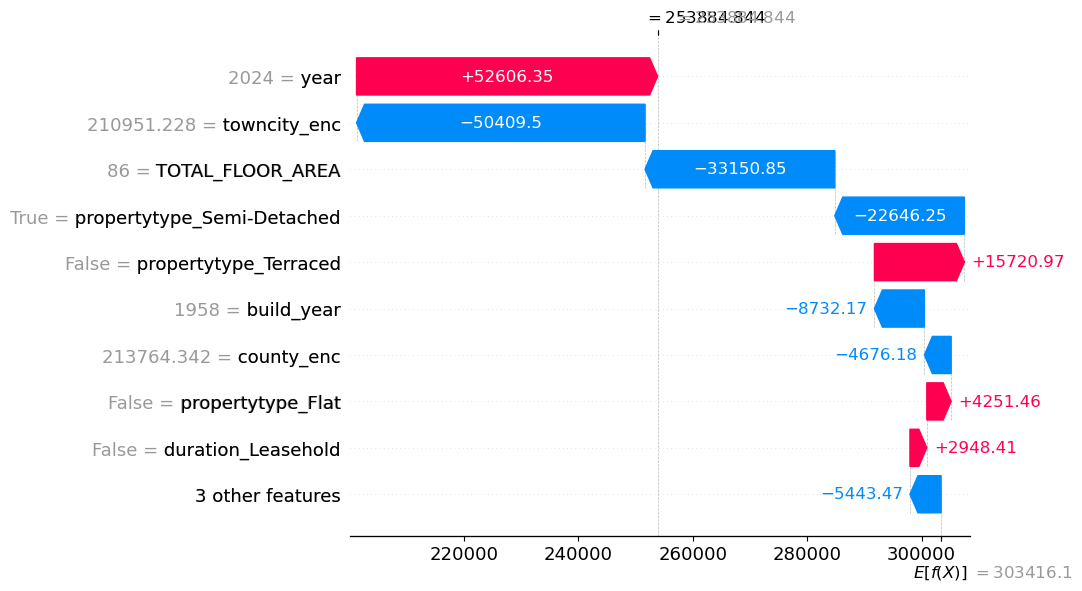

In [17]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=base_value,
        data=house.iloc[0],
        feature_names=list(X_test.columns)
    )
)

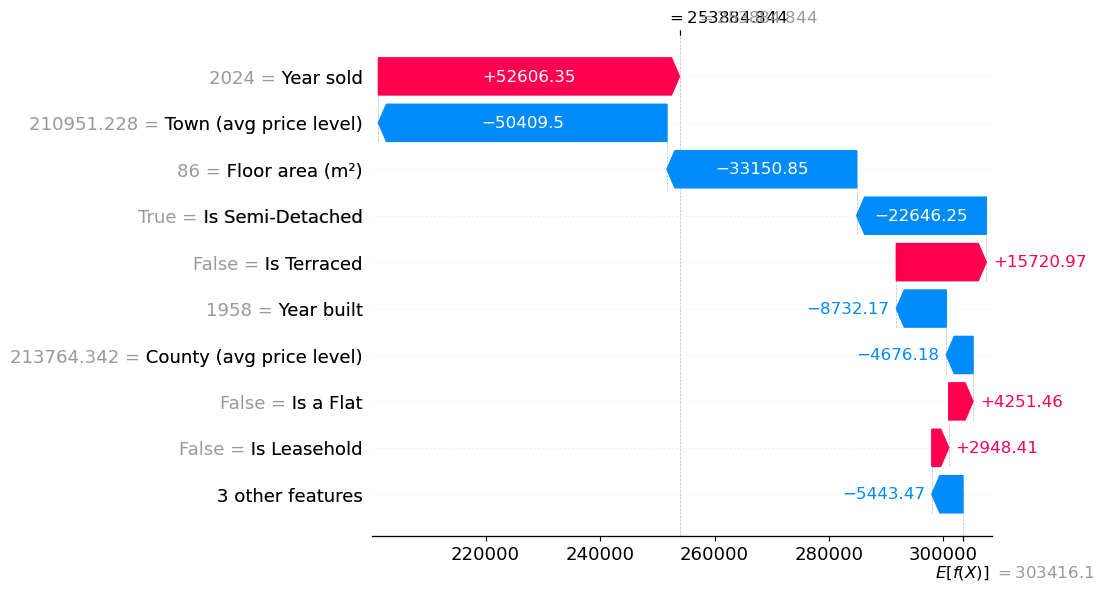

In [18]:
# Human-readable names for the plot
nice_names = {
    "year": "Year sold",
    "towncity_enc": "Town (avg price level)",
    "county_enc": "County (avg price level)",
    "TOTAL_FLOOR_AREA": "Floor area (m²)",
    "CURRENT_ENERGY_RATING": "Energy rating",
    "build_year": "Year built",
    "age_known": "Age recorded",
    "propertytype_Flat": "Is a Flat",
    "propertytype_Semi-Detached": "Is Semi-Detached",
    "propertytype_Terraced": "Is Terraced",
    "duration_Leasehold": "Is Leasehold",
    "oldnew_New Build": "Is New Build",
}

readable_cols = [nice_names.get(c, c) for c in X_test.columns]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=base_value,
        data=house.iloc[0],
        feature_names=readable_cols
    ),
    show=True
)

In [19]:
def explain_prediction(house_row, shap_row, base, top_n=5):
    pred = base + shap_row.sum()

    # Pair each feature with its SHAP value, sort by absolute impact
    impact = pd.Series(shap_row, index=X_test.columns)
    impact = impact.reindex(impact.abs().sort_values(ascending=False).index)

    lines = [f"Estimated price: £{pred:,.0f}", ""]
    lines.append("Main reasons for this estimate:")

    for feat, val in impact.head(top_n).items():
        up_down = "raised" if val > 0 else "lowered"
        amount = f"£{abs(val):,.0f}"
        actual_val = house_row[feat]

        # Translate each feature into a plain phrase
        if feat == "year":
            phrase = f"Sold in {int(actual_val)}"
        elif feat == "TOTAL_FLOOR_AREA":
            phrase = f"Floor area of {int(actual_val)} m²"
        elif feat == "towncity_enc":
            phrase = "The town's typical price level"
        elif feat == "county_enc":
            phrase = "The county's typical price level"
        elif feat == "build_year":
            phrase = f"Built around {int(actual_val)}"
        elif feat == "CURRENT_ENERGY_RATING":
            phrase = "The energy rating"
        elif feat == "propertytype_Semi-Detached":
            phrase = "Being semi-detached" if actual_val else "Not being semi-detached"
        elif feat == "propertytype_Terraced":
            phrase = "Being terraced" if actual_val else "Not being terraced"
        elif feat == "propertytype_Flat":
            phrase = "Being a flat" if actual_val else "Not being a flat"
        elif feat == "duration_Leasehold":
            phrase = "Being leasehold" if actual_val else "Being freehold"
        elif feat == "oldnew_New Build":
            phrase = "Being a new build" if actual_val else "Not being a new build"
        elif feat == "age_known":
            phrase = "Property age on record"
        else:
            phrase = feat

        lines.append(f"  • {phrase} {up_down} the estimate by about {amount}.")

    return "\n".join(lines)

# Test on the same house
print(explain_prediction(house.iloc[0], shap_values[0], base_value, top_n=5))

Estimated price: £253,885

Main reasons for this estimate:
  • Sold in 2024 raised the estimate by about £52,606.
  • The town's typical price level lowered the estimate by about £50,410.
  • Floor area of 86 m² lowered the estimate by about £33,151.
  • Being semi-detached lowered the estimate by about £22,646.
  • Not being terraced raised the estimate by about £15,721.


In [22]:
def explain_prediction(house_row, shap_row, base, top_n=3):
    pred = base + shap_row.sum()

    impact = pd.Series(shap_row, index=X_test.columns)
    impact = impact.reindex(impact.abs().sort_values(ascending=False).index)

    def round_nice(x):
        return round(abs(x) / 1000) * 1000

    lines = [f"Estimated price: about £{round(pred/1000)*1000:,.0f}", "", "Why:"]

    for feat, val in impact.head(top_n).items():
        up = val > 0
        amount = f"£{round_nice(val):,.0f}"
        v = house_row[feat]

        if feat == "year":
            phrase = "It's a recent sale" if up else "Older sale date"
        elif feat == "TOTAL_FLOOR_AREA":
            phrase = f"At {int(v)} m², it's {'larger' if up else 'smaller'} than average"
        elif feat == "towncity_enc":
            phrase = "The area sells above average" if up else "The area sells below average"
        elif feat == "county_enc":
            phrase = "The wider region sells above average" if up else "The wider region sells below average"
        elif feat == "build_year":
            phrase = "A newer property" if up else "An older property"
        elif feat == "CURRENT_ENERGY_RATING":
            phrase = "A good energy rating" if up else "A lower energy rating"
        elif feat == "propertytype_Semi-Detached" and v:
            phrase = "It's semi-detached"
        elif feat == "propertytype_Terraced" and v:
            phrase = "It's terraced"
        elif feat == "propertytype_Flat" and v:
            phrase = "It's a flat"
        elif feat.startswith("propertytype"):
            phrase = "Its property type"
        elif feat == "duration_Leasehold":
            phrase = "It's leasehold" if v else "It's freehold"
        elif feat == "oldnew_New Build":
            phrase = "It's a new build" if v else "It's an existing home"
        else:
            phrase = "Its property details"

        lines.append(f"  • {phrase} — {'adds' if up else 'reduces'} about {amount}.")

    return "\n".join(lines)

print(explain_prediction(house.iloc[0], shap_values[0], base_value, top_n=3))

Estimated price: about £254,000

Why:
  • It's a recent sale — adds about £53,000.
  • The area sells below average — reduces about £50,000.
  • At 86 m², it's smaller than average — reduces about £33,000.


In [23]:
for i in [10, 500, 12345]:
    h = X_test.iloc[[i]]
    sv = explainer.shap_values(h)
    print(f"--- House {i} ---")
    print(explain_prediction(h.iloc[0], sv[0], base_value, top_n=3))
    print()

--- House 10 ---
Estimated price: about £451,000

Why:
  • The area sells above average — adds about £162,000.
  • It's semi-detached — reduces about £24,000.
  • Older sale date — reduces about £19,000.

--- House 500 ---
Estimated price: about £444,000

Why:
  • The area sells above average — adds about £248,000.
  • At 62 m², it's smaller than average — reduces about £152,000.
  • The wider region sells above average — adds about £72,000.

--- House 12345 ---
Estimated price: about £264,000

Why:
  • At 125 m², it's larger than average — adds about £66,000.
  • It's terraced — reduces about £49,000.
  • The area sells below average — reduces about £29,000.



In [24]:
def monthly_payment(loan, annual_rate_pct, years=25):
    r = (annual_rate_pct / 100) / 12      # monthly interest rate
    n = years * 12                        # total number of payments
    if r == 0:
        return loan / n
    return loan * (r * (1 + r)**n) / ((1 + r)**n - 1)

def affordability(price, deposit_pct=10, base_rate=5.0, years=25):
    deposit = price * (deposit_pct / 100)
    loan = price - deposit

    print(f"Property price:   £{price:,.0f}")
    print(f"Deposit ({deposit_pct}%):    £{deposit:,.0f}")
    print(f"Loan amount:      £{loan:,.0f}")
    print(f"Term:             {years} years\n")

    print("Monthly payment if interest rates are:")
    for bump in [0, 1, 2, 3]:
        rate = base_rate + bump
        pay = monthly_payment(loan, rate, years)
        label = f"{rate:.1f}%" + ("  (current)" if bump == 0 else f"  (+{bump}%)")
        print(f"  {label:18s} £{pay:,.0f} / month")

# Test on a £254k property
affordability(254000, deposit_pct=10, base_rate=5.0, years=25)

Property price:   £254,000
Deposit (10%):    £25,400
Loan amount:      £228,600
Term:             25 years

Monthly payment if interest rates are:
  5.0%  (current)    £1,336 / month
  6.0%  (+1%)        £1,473 / month
  7.0%  (+2%)        £1,616 / month
  8.0%  (+3%)        £1,764 / month


In [25]:
affordability(254000, deposit_pct=10, base_rate=5.5, years=25)

Property price:   £254,000
Deposit (10%):    £25,400
Loan amount:      £228,600
Term:             25 years

Monthly payment if interest rates are:
  5.5%  (current)    £1,404 / month
  6.5%  (+1%)        £1,544 / month
  7.5%  (+2%)        £1,689 / month
  8.5%  (+3%)        £1,841 / month


In [26]:
# Validate against Rightmove's real-world figure: FTB property outside London
# £226,120, 80% LTV (20% deposit), ~5.1%, 25 years → they report ~£1,069/month
check = monthly_payment(180896, 5.1, 25)
print(f"Our calc: £{check:,.0f} / month  (Rightmove reports ~£1,069)")

Our calc: £1,068 / month  (Rightmove reports ~£1,069)
